In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

!pip install imutils opencv-python

import imutils
import cv2

DEPRECATION: Loading egg at c:\users\shantanu\anaconda3\lib\site-packages\matlabengine-25.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [3]:
!cd "C:\\Program Files\\MATLAB\\R2025a\\extern\\engines\\python" && python setup.py install

running install
running bdist_egg
running egg_info
writing dist\matlabengine.egg-info\PKG-INFO
writing dependency_links to dist\matlabengine.egg-info\dependency_links.txt
writing top-level names to dist\matlabengine.egg-info\top_level.txt
reading manifest file 'dist\matlabengine.egg-info\SOURCES.txt'
writing manifest file 'dist\matlabengine.egg-info\SOURCES.txt'
installing library code to build\bdist.win-amd64\egg
running install_lib
running build_py
creating build\bdist.win-amd64\egg
creating build\bdist.win-amd64\egg\matlab
creating build\bdist.win-amd64\egg\matlab\engine
copying build\lib\matlab\engine\basefuture.py -> build\bdist.win-amd64\egg\matlab\engine
copying build\lib\matlab\engine\engineerror.py -> build\bdist.win-amd64\egg\matlab\engine
copying build\lib\matlab\engine\enginehelper.py -> build\bdist.win-amd64\egg\matlab\engine
copying build\lib\matlab\engine\enginesession.py -> build\bdist.win-amd64\egg\matlab\engine
copying build\lib\matlab\engine\fevalfuture.py -> build\b

C:\Users\Shantanu\anaconda3\Lib\site-packages\setuptools\_distutils\cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
C:\Users\Shantanu\anaconda3\Lib\site-packages\setuptools\_distutils\cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://g

In [59]:
import sys
sys.path.append(r"C:\Users\Shantanu\anaconda3\lib\site-packages\matlabengine-25.1-py3.12.egg")
import matlab.engine

eng = matlab.engine.start_matlab()

In [93]:
path = "brain_mri_dataset/Training/"
labels = ["glioma", "meningioma", "notumor", "pituitary"]
labels_sym = dict({
    "glioma": "gl",
    "meningioma": "me",
    "notumor": "no",
    "pituitary": "pi"
})

picked_label = random.choice(labels)
picked_image = random.randint(10, 55)

brain_mri_dataset/Training/glioma/Tr-gl_0020.jpg


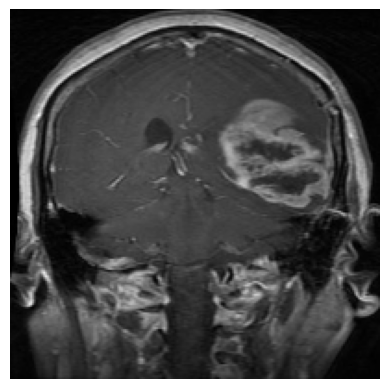

In [95]:
def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

	return new_img

# Pick a random file from the list of filenames.
image_path = path + picked_label + "/" + "Tr-" + labels_sym[picked_label] + "_00" + str(picked_image) + ".jpg"
print(image_path)

# Load and preprocess the image
IMG_SIZE = 200
image = cv2.imread(image_path)

cropped = crop_img(image)
resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()

In [97]:
output = eng.MRI_Orientation_Classifier(image_path)
print("Prediction from MATLAB NN:", output)

Prediction from MATLAB NN: T1coronal


In [73]:
image_orientations = dict({})

directory = path + "glioma"

for image in os.listdir(directory):

    if image[len(image) - 4:len(image)] != ".jpg":
        continue

    output = eng.MRI_Orientation_Classifier(directory + "/" + image)

    if output in image_orientations:
        image_orientations[output].append("glioma/" + image)
    else:
        image_orientations[output] = [image]

In [74]:
directory = path + "meningioma"

for image in os.listdir(directory):

    if image[len(image) - 4:len(image)] != ".jpg":
        continue

    output = eng.MRI_Orientation_Classifier(directory + "/" + image)

    if output in image_orientations:
        image_orientations[output].append("meningioma/" + image)
    else:
        image_orientations[output] = [image]

In [75]:
directory = path + "notumor"

for image in os.listdir(directory):

    if image[len(image) - 4:len(image)] != ".jpg":
        continue

    output = eng.MRI_Orientation_Classifier(directory + "/" + image)

    if output in image_orientations:
        image_orientations[output].append("notumor/" + image)
    else:
        image_orientations[output] = [image]

In [76]:
directory = path + "pituitary"

for image in os.listdir(directory):

    if image[len(image) - 4:len(image)] != ".jpg":
        continue

    output = eng.MRI_Orientation_Classifier(directory + "/" + image)

    if output in image_orientations:
        image_orientations[output].append("pituitary/" + image)
    else:
        image_orientations[output] = [image]

In [81]:
print(list(image_orientations.keys()))

['T1coronal', 'PDaxial', 'PDcoronal', 'T2sagittal', 'T1axial', 'PDsagittal', 'T1sagittal', 'T2axial', 'T2coronal', 'FLAIRaxial', 'FLAIRsagittal', 'FLAIRcoronal']


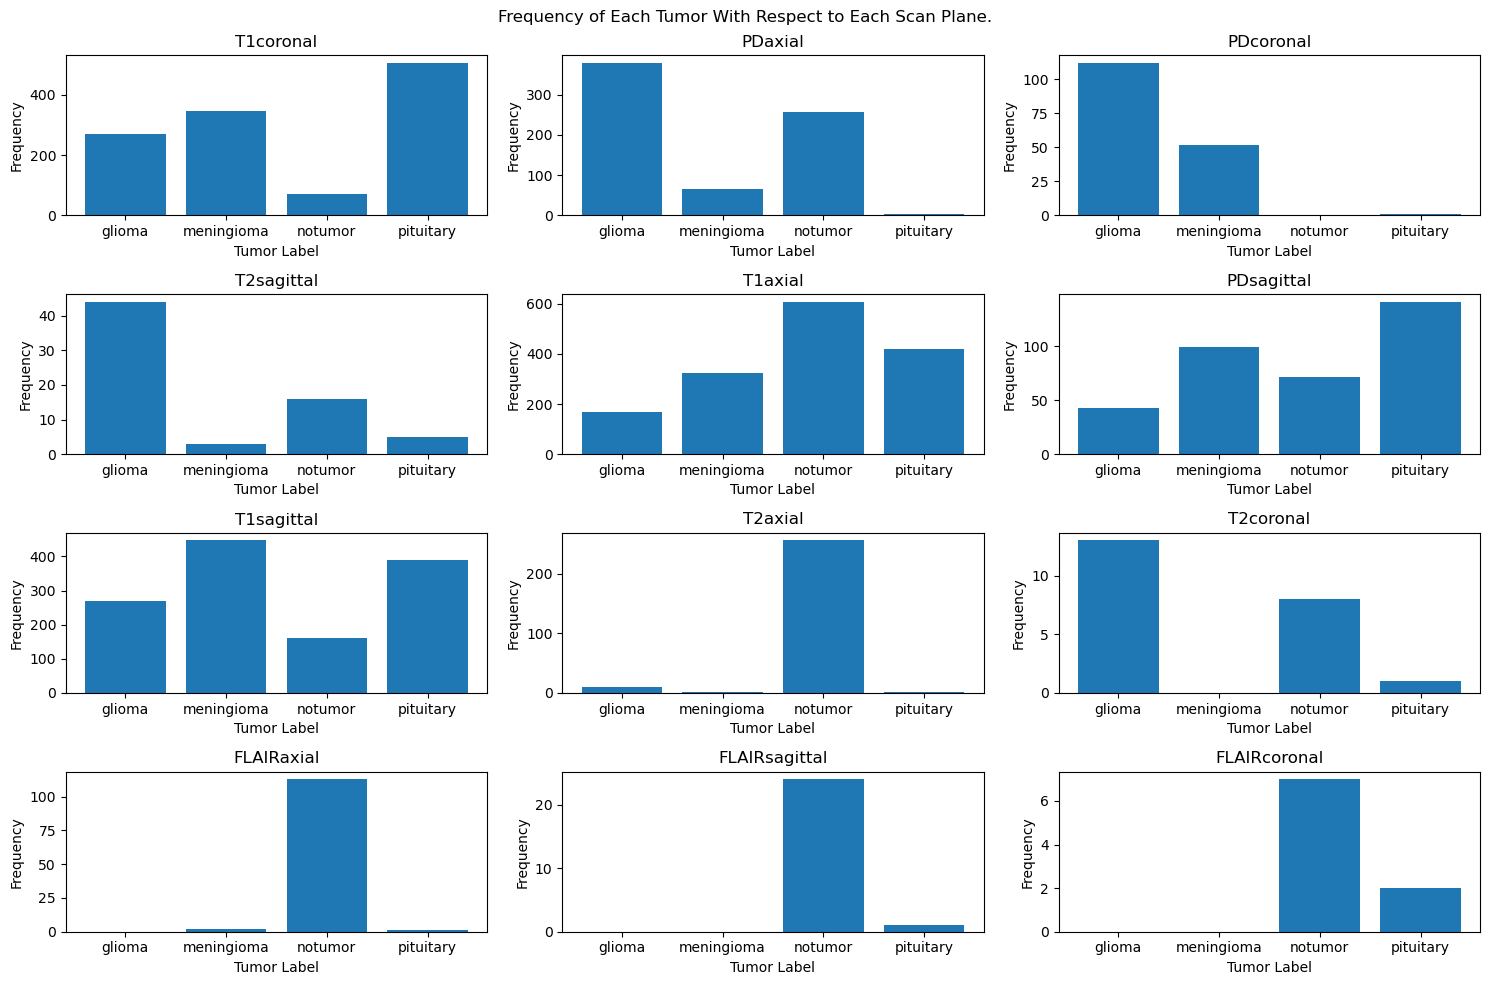

In [91]:
chart_num = 1

plt.figure(figsize=(15, 10))
plt.suptitle("Frequency of Each Tumor With Respect to Each Scan Plane.")

for orientation in image_orientations:

    counts = [0, 0, 0, 0]

    imgs = image_orientations[orientation]

    for i in range(len(imgs)):

        if "glioma" in imgs[i]:
            counts[0] += 1
        elif "meningioma" in imgs[i]:
            counts[1] += 1
        elif "notumor" in imgs[i]:
            counts[2] += 1
        else:
            counts[3] += 1
            
    
    plt.subplot(4, 3, chart_num)
    plt.bar(labels, counts)
    plt.xlabel("Tumor Label")
    plt.ylabel("Frequency")
    plt.title(orientation)

    chart_num += 1

plt.tight_layout()
plt.show()

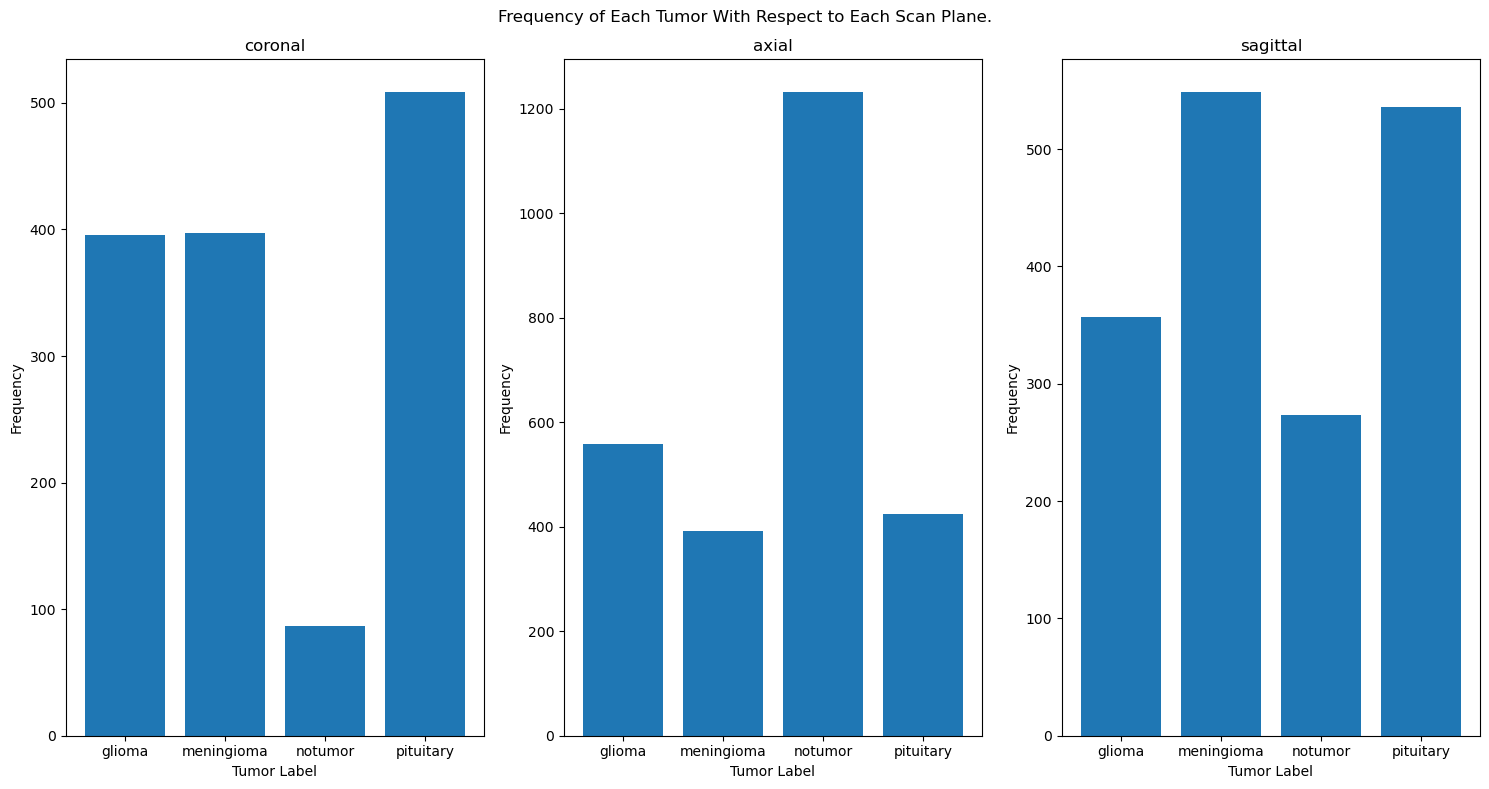

In [111]:
fundamental_planes = dict({
    "coronal": [],
    "axial": [],
    "sagittal": []
})

for orientation in image_orientations:

    if "coronal" in orientation:
        fundamental_planes["coronal"] += image_orientations[orientation]
    elif "axial" in orientation:
        fundamental_planes["axial"] += image_orientations[orientation]
    else:
        fundamental_planes["sagittal"] += image_orientations[orientation]

chart_num = 1

plt.figure(figsize=(15, 8))
plt.suptitle("Frequency of Each Tumor With Respect to Each Scan Plane.")

for plane in fundamental_planes:

    counts = [0, 0, 0, 0]

    imgs = fundamental_planes[plane]

    for i in range(len(imgs)):

        if "glioma" in imgs[i]:
            counts[0] += 1
        elif "meningioma" in imgs[i]:
            counts[1] += 1
        elif "notumor" in imgs[i]:
            counts[2] += 1
        else:
            counts[3] += 1
            
    
    plt.subplot(1, 3, chart_num)
    plt.bar(labels, counts)
    plt.xlabel("Tumor Label")
    plt.ylabel("Frequency")
    plt.title(plane)

    chart_num += 1

plt.tight_layout()
plt.show()